In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=UserWarning)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.optimize import minimize
from joblib import Parallel, delayed
from tqdm.auto import tqdm

output_file         = '../05_output/'
osap_data           = '../03_data/osap/'

temp_dir = "D:/github_repositories"
os.environ["TEMP"] = temp_dir
os.environ["TMP"] = temp_dir
os.environ["JOBLIB_TEMP_FOLDER"] = temp_dir
os.environ['PYTHONWARNINGS'] = 'ignore'

In [2]:
signalnames         = np.load(osap_data + 'signalnames.npy', allow_pickle=True)
date                = np.load(osap_data + 'date.npy')
ret                 = np.load(osap_data + 'ret.npy')
signals             = np.load(osap_data + 'signals.npy')

In [3]:
def equal_weight(ret, signals):
    N, T            = ret.shape
    valid           = ~np.isnan(ret) & ~np.any(np.isnan(signals), axis=2)
    Nt              = np.sum(valid, axis=0, keepdims=True)
    Nt_mat          = np.tile(Nt, (N, 1))
    weight          = np.where(valid, 1/Nt_mat, np.nan)
    return weight

def value_weight(ret, size):
    me              = size[:, :] 
    valid           = ~np.isnan(ret) & ~np.isnan(me)
    me              = np.where(valid, me, 0)
    totme           = np.sum(me, axis=0, keepdims=True)
    weight          = np.where(valid, me/totme, np.nan)
    return weight

def ppp_port(ret, signals, delta, gamma, p):
    def utilityf(rp, gamma):
        if gamma == 1:
            return cp.log(1+rp)
        else:
            return cp.power(1+rp, 1-gamma)/(1-gamma)
    
    N, T, L         = signals.shape
    valid           = ~np.isnan(ret) & ~np.any(np.isnan(signals), axis=2)
    Nt              = np.sum(valid, axis=0, keepdims=True)
    Nt_mat          = np.tile(Nt, (N, 1))

    signals         = np.where(valid[:, :, np.newaxis], signals, 0.0)
    ret             = np.where(valid, ret, 0.0)

    theta           = cp.Variable((L, 1))
    w               = cp.multiply(cp.squeeze(signals.transpose((1, 0, 2)) @ theta, axis=2), 1/Nt_mat.T) + valid.T/Nt_mat.T
    rp              = cp.sum(cp.multiply(w, ret.transpose(1, 0)), axis=1)
    u               = utilityf(rp, gamma)

    objective       = cp.Minimize(- cp.mean(u) + delta*cp.norm(theta, p))
    # constraints = [w >= 0]
    prob            = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    return theta.value.reshape(-1, 1)

In [4]:


def _single_step(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p, s):
    rng                 = np.random.default_rng(45 + s)
    train_ret           = ret[:, :i+train_len] # ret_cut[:, :-1]
    train_chars         = signals[:, :i+train_len, :] # chars_cut[:, :-1, :]
    train_chars         = (train_chars - np.nanmean(train_chars, axis=0, keepdims=True))/np.nanstd(train_chars, axis=0, keepdims=True)

    test_ret            = ret[:, i+train_len:i+train_len+1] # ret_cut[:, -1:]
    test_chars          = signals[:, i+train_len:i+train_len+1, :] # chars_cut[:, -1:, :]
    test_size           = size[:, i+train_len:i+train_len+1] # size_cut[:, -1:]
    valid               = (~np.isnan(test_ret) & ~np.any(np.isnan(test_chars), axis=2))
    if np.sum(valid) > port_num and port_num != -1:
        valid_idx           = np.where(valid.flatten())[0]
        idx                 = rng.permutation(valid_idx)[:port_num]
        new_valid           = np.zeros_like(valid)
        new_valid[idx, :]   = 1
    else:
        new_valid           = valid

    test_ret           = np.where(new_valid, test_ret, np.nan)
    test_chars          = np.where(np.tile(new_valid[:, :, np.newaxis], (1, 1, signals.shape[2])), test_chars, np.nan)
    test_chars          = (test_chars - np.nanmean(test_chars, axis=0, keepdims=True))/np.nanstd(test_chars, axis=0, keepdims=True)

    wlist = []

    # equal weight
    weight_e            = equal_weight(test_ret, test_chars)

    # value weight
    weight_v            = value_weight(test_ret, test_size)

    # ppp weight
    theta               = ppp_port(train_ret, train_chars, delta=0, gamma=5, p=2)
    weight_ppp          = np.squeeze(test_chars @ theta, axis=2)*weight_e + weight_e

    weight_e            = np.where(new_valid, weight_e, 0)
    weight_v            = np.where(new_valid, weight_v, 0)
    weight_ppp          = np.where(new_valid, weight_ppp, 0)

    wlist.append(np.squeeze(weight_e, axis=1))
    wlist.append(np.squeeze(weight_v, axis=1))
    wlist.append(np.squeeze(weight_ppp, axis=1))
    
    test_ret           = np.where(new_valid, test_ret, 0)
    port_ret = np.full((strategy_num, 1), np.nan)
    for j, weight in enumerate(wlist):
        weight              = np.where(~np.isnan(weight), weight, 0)
        port_ret[j]         = (weight @ test_ret[:, :])
    
    return i, port_ret

def evaluate(ret, signals, size, train_len, port_num, strategy_num, use_chars=0, p=2, s=0, n_jobs=1):
    N, T, L             = signals.shape
    T_steps             = T-train_len-1
    with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
        warnings.filterwarnings('ignore')
        results = dict(parallel(
            delayed(_single_step)(i, ret, signals, size, train_len, port_num, strategy_num, use_chars, p, s) for i in tqdm(range(T_steps))
        ))

    port_ret            = np.full((strategy_num, T_steps), np.nan)
    for k, v in results.items():
        port_ret[:, k:k+1] = v

    return port_ret

In [ ]:
charslist           = np.where(np.isin(signalnames, ['BM', 'Size', 'Mom12m']))[0]
sizelist            = np.where(np.isin(signalnames, ['Size']))[0][0]
port_ret            = evaluate(
                        ret[:, :, 0], 
                        signals[:, :, charslist], 
                        signals[:, :, sizelist], 
                        train_len=120, 
                        port_num=-1, 
                        strategy_num=3, 
                        use_chars=0, 
                        p=2, s=0, n_jobs=-1
                    )
results             = pd.DataFrame({
                        'mean':         np.round(np.mean(port_ret, axis=1)*12, 4), 
                        'std':          np.round(np.std(port_ret, axis=1)*np.sqrt(12), 4),
                        'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
                    }, index=['equal weited', 'value weighted', 'ppp'])
results

100%|██████████| 527/527 [02:46<00:00,  3.17it/s]


,mean,std,sharpe ratio
equal weited,0.1430,0.1900,0.7527
value weighted,0.1387,0.1825,0.7599
ppp,0.3061,0.2973,1.0294


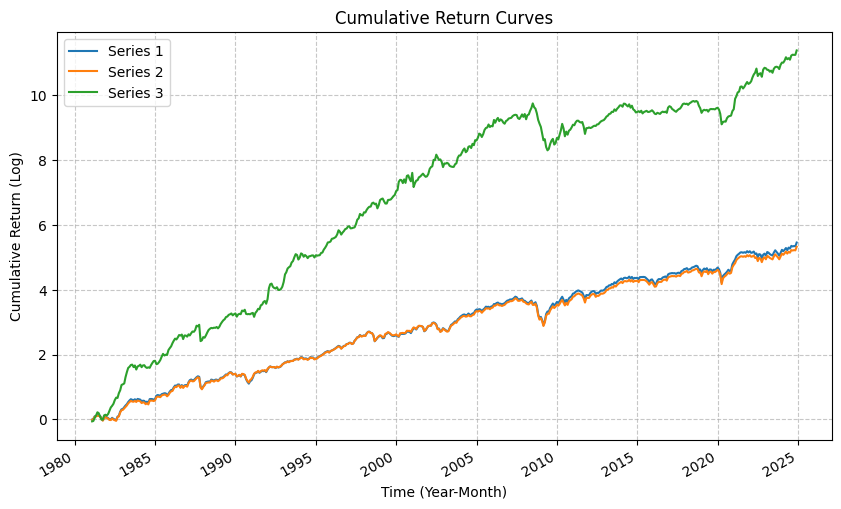

In [6]:
def plot_cumulative_returns(x_axis, *return_series):
    plt.figure(figsize=(10, 6))
    x_date = pd.to_datetime(x_axis, format='%Y%m', errors='coerce')
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        cumulative = np.cumsum(np.log(1 + series))
        
        plt.plot(x_date, cumulative, label=f"Series {i}")
    
    # 自动调整日期标签的倾斜度，防止重叠
    plt.gcf().autofmt_xdate()
    
    plt.xlabel("Time (Year-Month)")
    plt.ylabel("Cumulative Return (Log)")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_cumulative_returns(date[121:], port_ret[0], port_ret[1], port_ret[2])

In [7]:
charslist           = np.where(np.isin(signalnames, ['BM', 'Size', 'Mom12m']))[0]
sizelist            = np.where(np.isin(signalnames, ['Size']))[0][0]
start_date          = np.where(np.isin(date, [199101]))[0][0]

sharpe_ratio        = []
for port_num in range(100, 1501, 100):
    port_ret            = evaluate(
                            ret[:, start_date:, 0], 
                            signals[:, start_date:, charslist], 
                            signals[:, :, sizelist], 
                            train_len=120, 
                            port_num=port_num, 
                            strategy_num=3, 
                            use_chars=0, 
                            p=2, s=0, n_jobs=-1
                        )
    sharpe_ratio.append(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)))


100%|██████████| 287/287 [01:23<00:00,  3.45it/s]


In [10]:
for port_num in range(1500, 2501, 100):
    port_ret            = evaluate(
                            ret[:, start_date:, 0], 
                            signals[:, start_date:, charslist], 
                            signals[:, :, sizelist], 
                            train_len=120, 
                            port_num=port_num, 
                            strategy_num=3, 
                            use_chars=0, 
                            p=2, s=0, n_jobs=-1
                        )
    sharpe_ratio.append(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)))


100%|██████████| 287/287 [01:41<00:00,  2.84it/s]


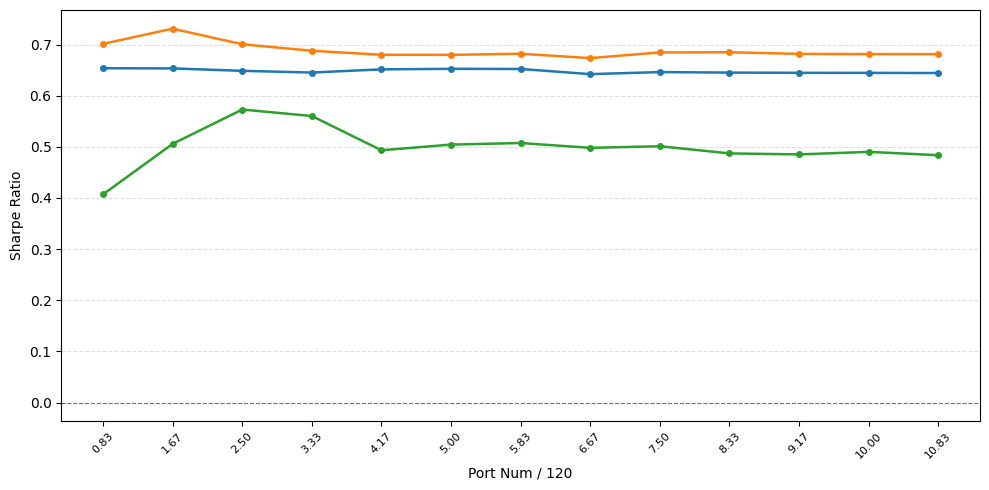

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(100, 1301, 100) / 120

plt.figure(figsize=(10, 5))
plt.plot(x, sharpe_ratio[:13], marker='o', markersize=4, linewidth=1.8)
plt.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
plt.xticks(x, rotation=45, fontsize=8)
plt.xlabel('Port Num / 120')
plt.ylabel('Sharpe Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()